<a href="https://colab.research.google.com/github/johnryantaylor/QCES/blob/main/Project1_numerical_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Heat transport

In this project we will discretize and timestep two systems that describe heat transport. In the first part we will timestep a box model for the Earth's surface temperature with heat buffering provided by the deep ocean. In the second part, we will timestep the one-dimensional diffusion equation which can be used to describe heat moving through a medium (e.g. the ground or still air and water).

Through this project, we will learn how to efficiently timestep ordinary and partial differential equations and examine errors introduced by the numerical discretization. We will also have the chance to explore the timescales and physical processes involved in heat transport in the climate system.

## 1. Climate box model

In this part of the project we will timestep the following box model.

$$ C_s \partial_t T = F(t) - \gamma(T-\theta) $$

$$ C_d \partial_t \theta = \gamma (T-\theta) $$

Here, $T(t)$ represents the global mean surface temperature as a function of time and $\theta(t)$ is the temperature of the deep ocean, both expressed as the difference between the temperature and a pre-industrial equilibrium in units of $^\circ K$. The net surface heat flux, $F(t)$, drives departures from the pre-industrial temperatures. The heat flux between the surface and deep ocean is assumed to be proportional to the difference between the surface and deep ocean temperatures. The constants are the heat capacity of the surface of the Earth, $C_s$, the heat capacity of the deep ocean, $C_d$, and the heat flux coefficient, $\gamma$, all given in units of $W/^\circ K/m^2$. Note that $C_s$ and $C_d$ (as defined in Nicklas et al. 2025) are heat capacities per year; i.e. $1/C_s$ tells us how much the surface temperature would increase if a flux of 1 $W/m^2$ were applied for one year.

This model is inspired by a more complicated version of a two box climate model in the paper referenced below. (Interested students might consider adding some additional features from their model, but this is not required for this project).

*Nicklas, J.M., Fox-Kemper, B. and Lawrence, C., 2025. Efficient Estimation of Climate State and Its Uncertainty Using Kalman Filtering with Application to Policy Thresholds and Volcanism. Journal of Climate, 38(5), pp.1235-1270.*

Below, we start to build code to solve these equations. Execute the code cells below.  In some cases you will be asked to add code.

Student tasks are in [Section 1.1](#section1pt1), [Section 1.2](#section1pt2), and [Section 1.3](#section1pt3).

In [1]:
# Before we start, import necessary libraries. Run this cell first.
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import time

Now, let's define values for the various constants. These values are taken from Nicklas et al., 2025.

In [2]:
C_s = 17 # heat capacity of the Earth's surface (W/m^2/K)
C_d = 156 # heat capacity of the deep ocean (W/m^2/K)
gamma = 0.67 # heat exchange coefficient between surface and deep ocean (W/m^2/K)

Now, let's define a function for F(t), the net surface heat flux (in units of $W/m^2$) that will force our model. This function is here to represent the heat imbalance caused by antropogenic greenhouse gases in the atmosphere. When $F=0$, there is no net surface heat flux. The argument, $t$, is the time in years. We will let $t=0$ denote the start of our additional warming, and we set $F=1$ if $t<200$ years and $F=0$ if $t>200$ years. This corresponds to a very bad-case emissions scenario with an abrupt drop in emissions after 200 years.

In [3]:
def F(t):
    return 1 if t < 200 else 0

Next, set the initial conditions. We will use arrays `T` and `theta`. `T[i]` represents the ith value in the array. We will use `T[0]` and `theta[0]` to hold the initial conditions. Subsequent values, `T[2]`, `T[3]`, etc. will be determined by timestepping the equations. We start by initializing the arrays using numpy and filling them with zeros and then set the initial values (this isn't necessary here since our values are zero anyway, but the code is here to that you can change the initial conditions easily)

In [4]:
Nt = 500 # number of time steps (including the starting point)
T = np.zeros(Nt) # surface temperature array
theta = np.zeros(Nt) # deep ocean temperature array
T[0] = 0 # initial surface temperature anomaly (ºK)
theta[0] = 0 # initial deep ocean temperature anomaly (ºK)

Now, create an array with the time (in years) corresponding to each time index. Also, calculate the timestep, `dt`.

In [5]:
t = np.linspace(0, 500, Nt) # time in years.  This starts at 0 and ends at 500, with Nt total points
dt = t[1] - t[0] # timestep in years

Finally, we are ready to create a for loop to timestep the equations listed at the top of the section.

### 1.1 Student task:
<a id='section1pt1'></a>
Fill in the interior of the for loop to timestep the equations from the start of Section 1 using the Explicit Euler method.

In [6]:
for i in range(0, Nt-1):
    T[i+1] = T[i] + ((F(i) - gamma * (T[i] - theta[i]))/C_s * dt)
    theta[i+1] = theta[i] + (gamma * (T[i] - theta[i]) / C_d * dt)

After you are finished, run the cell below to plot the results

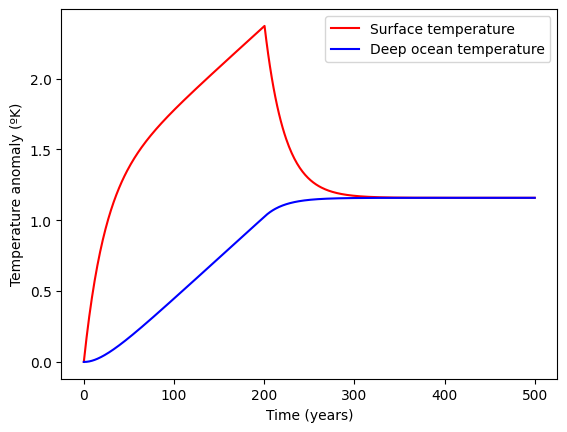

In [7]:
plt.plot(t,T,'r-')
plt.plot(t,theta,'b-')
plt.legend(['Surface temperature','Deep ocean temperature'])
plt.xlabel('Time (years)')
plt.ylabel('Temperature anomaly (ºK)')
plt.show()

### 1.2 Student task
<a id='section1pt2'></a>
Discuss the rates of change the temperature of the Earth's surface and the deep ocean at the start of the model run.  Can you explain the response of $T$ and $\theta$ to the forcing by defining characteristic timescales from the box model equations?

**ANSWER:** Let us define $\Delta$ as $T - θ.$ We can thus rewrite the the box model equations as follows:

$$\partial_t \Delta = \frac{F(t)}{C_s} - \gamma \Delta (\frac{1}{C_s} + \frac{1}{C_d}).$$

Our characteristic timescale for T and $\theta$ to respond to a forcing is thus $\frac{1}{\gamma (\frac{1}{C_s} + \frac{1}{C_d})}.$ With our given constants, this suggests a characteristic timescale of $\tau ≈ 23$ years. This means that given a change in $F(t)$ (or in this case, $F(t)$ and $C_s$) it will take approximately 23 years to adjust to the forcing. We see this not only at the start of the model run but when the forcing goes back to zero in 200 years. An increase in surface and deep ocean temperatures will occur until we reach equilibrium. This occurs when $\partial_t \Delta = 0.$ With our given constants, the stable solution occurs at $\Delta = 1.35$ degrees.

### 1.3 Student task
<a id='section1pt3'></a>
Modify the forcing function, `F(t)` above with 2-3 scenarios of your choice. Plot the temperature response for each scenario and briefly (2-3 sentences each) describe the temperature responses in each scenario. You will need to replicate some of the code blocks above so that you can produce a new set of plots below.

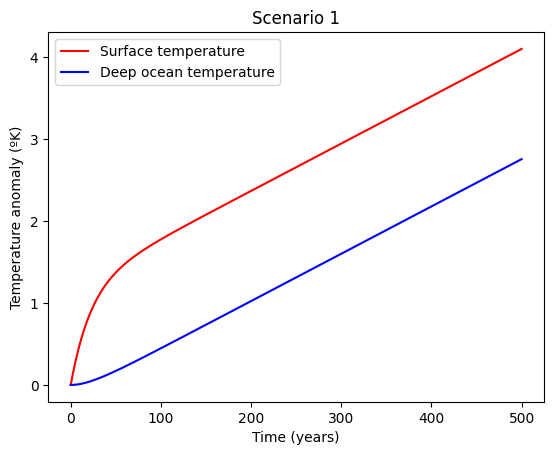

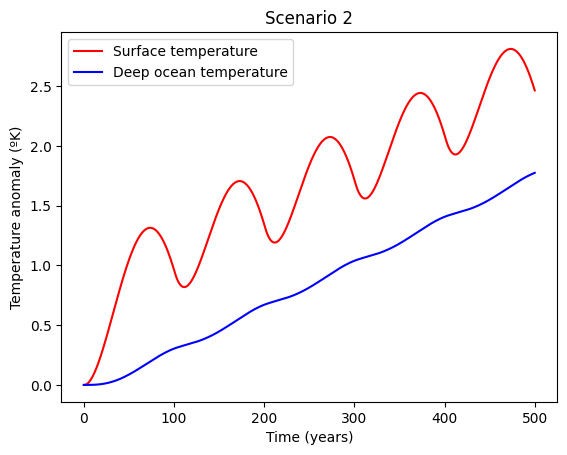

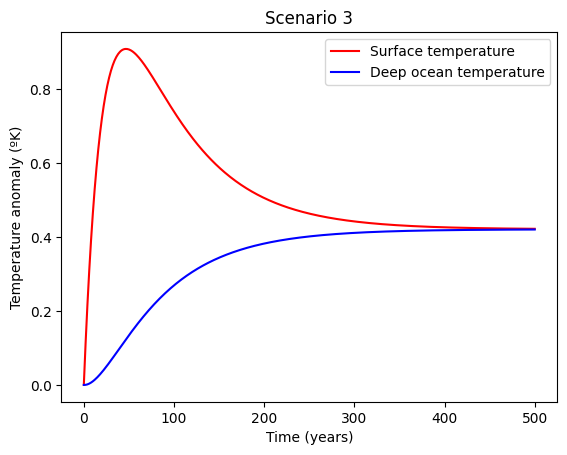

In [8]:
Nt = 500 # number of time steps (including the starting point)
T = np.zeros(Nt) # surface temperature array
theta = np.zeros(Nt) # deep ocean temperature array
T[0] = 0 # initial surface temperature anomaly (ºK)
theta[0] = 0 # initial deep ocean temperature anomaly (ºK)

def F_scenario_1(t):
  return 1

def F_scenario_2(t):
  return abs(np.sin(np.pi * t/100))

def F_scenario_3(t):
  return 0.5 ** (t/50)

scenario_counter = 1
for scenario in [F_scenario_1, F_scenario_2, F_scenario_3]:

  Nt = 500 # number of time steps (including the starting point)
  T = np.zeros(Nt) # surface temperature array
  theta = np.zeros(Nt) # deep ocean temperature array
  T[0] = 0 # initial surface temperature anomaly (ºK)
  theta[0] = 0 # initial deep ocean temperature anomaly (ºK)

  t = np.linspace(0, 500, Nt) # time in years.  This starts at 0 and ends at 500, with Nt total points
  dt = t[1] - t[0] # timestep in years

  for i in range(0, Nt-1):
    T[i+1] = T[i] + (((scenario(i) - gamma * (T[i] - theta[i]))/C_s) * dt)
    theta[i+1] = theta[i] + (gamma * (T[i] - theta[i]) / C_d * dt)

  plt.plot(t,T,'r-')
  plt.plot(t,theta,'b-')
  plt.legend(['Surface temperature','Deep ocean temperature'])
  plt.xlabel('Time (years)')
  plt.ylabel('Temperature anomaly (ºK)')
  plt.title(f'Scenario {scenario_counter}')
  scenario_counter += 1
  plt.show()


**ANSWER:** In scenario 1, we have a consistently bad emissions case that is equivalent to saying no environmental regulation has been enacted. We can see that the surface temperature and deep ocean temperature responds to the initial forcing but reaches a steady, linear growth (see my answer for section 1.2). In scenario 2, we have a sinosoidal emissions scenario where emissions fluctuate every 50 years (reaching a peak in 50 years and reaching a valley in the next 50 years). We see that the surface temperature exhibits consistent growth with periodic fluctations and a slight lag from the intial forcing. This same behavior is found in the deep ocean with a lower amplitude which is a consequence of the deep ocean's high heat capacity. In scenario 3, we have an emissions scenario where the forcing from the emissions decay exponentially in half every 50 years. We see that the initial forcing rapidly increases the surface temperature but decays quickly to equilibrium when both the temperature of the surface and deep ocean are the same. This suggests that the deep ocean is a powerful heat sink to mitigate climate warming. In this scenario, the overall temperature only increased by around 0.4 degrees.

## 2. Diffusion equation

In this part of the project we will solve the 1-D diffusion equation:

$$ \partial_t c = \kappa \partial_x^2 c $$

We will use second order finite differences to approximate the $x$-derivatives, and we will implement and compare two timestepping methods.

Student tasks are in [Section 2.1](#section2pt1), [Section 2.2](#section2pt2), and [Section 2.3](#section2pt3).

First, let's discretize the second order derivative using finite differences. The function below builds a coefficient matrix, $M$, so that $Mc$ is a discretized version of $\partial^2_x c$, where in our discretized version $c$ is a column vector.

In [9]:
    def construct_M(x):
    # Build a coefficient matrix, such that M*c is the discrete version of d^2/dx^2(c)
        dx = x[1] - x[0]  # Infer the uniform grid spacing
        M = (np.diag(np.ones(Nx-1), -1) - 2*np.diag(np.ones(Nx), 0) + np.diag(np.ones(Nx-1), 1)) / dx**2
        M = sp.csr_matrix(M) # Turn M into a sparse matrix to save memory and improve speed
        return M

Now, define two functions to timestep the diffusion equation. The code below timesteps the diffusion equation using the expicit Euler method. The function takes in a vector of discrete positions, `x`, discrete times, `t`, and the diffusivity, `kappa`. The vectors `x` and `t` dictate the discretization of the problem in space and time, and the grid spacing must be constant in space and time. The boundary conditions are $\partial_x c=0$ at the starting and ending points in `x`.

In [10]:
def EE(x, t, kappa):
# This function timesteps the diffusion equation with homogeneous Neumann boundary conditions
# using the explicit Euler and second order finite difference methods

    start_time = time.time()  # Start a timer

    # Infer the timestep from the time array
    dt = t[1] - t[0]

    M = construct_M(x)  # Construct the coefficient matrix for the second derivative

    # Set the number of gridpoints in x and t
    Nx = len(x); Nt = len(t)

    # Create an empty sparse array to store the solution
    c = np.zeros((Nx, Nt))

    c[:, 0] = set_ics(x, kappa, 10)  # Set the initial condition

    for k in range(1, Nt):  # loop over the number of timesteps
      c[:,k] = c[:,k-1] + dt * kappa * M @ c[:,k-1]
      # Enforce the boundary conditions (no flux)
      c[0, k] = c[1, k]
      c[-1, k] = c[-2, k]

    end_time = time.time()  # Print the elapsed time

    print(f"Explicit Euler method took {end_time - start_time:.2f} seconds")

    return c

Similarly, the function below timesteps the diffusion equation with the Crank-Nicolson method

In [11]:
def CN(x, t, kappa):
# This function timesteps the diffusion equation with homogeneous Neumann boundary conditions
# using the explicit Euler and second order finite difference methods
    start_time = time.time()  # Start a timer

    # Infer the timestep from the time array
    dt = t[1] - t[0]

    M = construct_M(x)  # Construct the coefficient matrix for the second derivative

    # Set the number of gridpoints in x and t
    Nx = len(x); Nt = len(t)

    A = sp.eye(Nx) - 0.5 * dt * kappa * M  # This matrix appears on the LHS in the C-N scheme
    A_inv = spla.inv(A) # Calculate the inverse of A (this only needs to be done once)

    # Create an empty sparse array to store the solution
    c = np.zeros((Nx, Nt))

    c[:, 0] = set_ics(x, kappa, 10)  # Set the initial condition

    for k in range(1, Nt): # loop over the number of timesteps
        c[:, k] = A_inv @ (c[:, k-1] + 0.5 * dt * kappa * (M @ c[:, k-1]))
        # Enforce the boundary conditions
        c[0, k] = c[1, k]
        c[-1, k] = c[-2, k]

    end_time = time.time()  # Print the elapsed time

    print(f"Crank-Nicolson method took {end_time - start_time:.2f} seconds")

    return c

Next, create a function to set the initial conditions. The exact solution to the unbounded diffusion equation with a delta function initial condition is:

$$\left(\frac{1}{4\pi\kappa t}\right)^{1/2}e^{-x^2/(4\kappa t)}$$

The function below sets the initial condition by evaluating the exact solution at a given time. Note that it is important that we don't evaluate the exact solution at `t_ic=0` since this will return a delta function which will be undefined on our finite grid. The value of `t_ic` is set within the `EE` and `CN` functions.

In [12]:
# Function to set the initial condition from the exact solution at time t_start
def set_ics(x, kappa, t_ic):
    c_ic = (4*np.pi*kappa*t_ic)**(-0.5)*np.exp(-x**2 / (4*kappa*t_ic))
    # Enforce the boundary conditions
    c_ic[0] = c_ic[1]
    c_ic[-1] = c_ic[-2]
    return c_ic


Finally, define some parameters and the x and t vectors:

In [13]:
# Defining parameters
kappa = 0.001  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time
Nt = 1000  # number of timesteps

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 100

t = np.linspace(t_start, t_end, Nt)  # Create a vector of times
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

Run each method once:

In [14]:
# Run the simulations
c_EE = EE(x, t, kappa) # explicit Euler
c_CN = CN(x, t, kappa) # Crank-Nicolson

Explicit Euler method took 0.23 seconds


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Crank-Nicolson method took 0.34 seconds


and finally, plot the results side-by-side

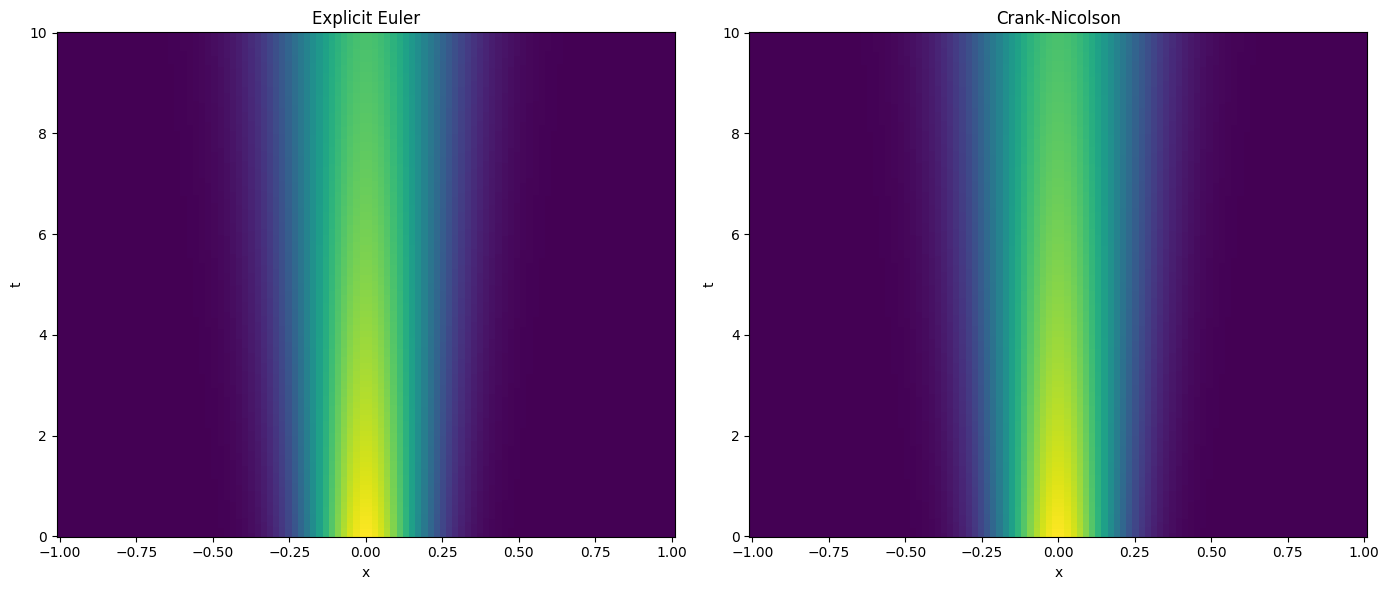

In [15]:
# Plot the results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pcolormesh(x, t, c_EE.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Explicit Euler')

plt.subplot(1, 2, 2)
plt.pcolormesh(x, t, c_CN.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Crank-Nicolson')

plt.tight_layout()
plt.show()

## 2. Student investigation

### 2.1 Stability
<a id='section2pt1'></a>
The explicit Euler and Crank-Nicolson methods have different stability properties. To explore this, try increasing the diffusivity, $\kappa$, and see how each method responds. Discuss your findings below (~2-3 sentences).

Explicit Euler method took 0.21 seconds
Crank-Nicolson method took 0.44 seconds


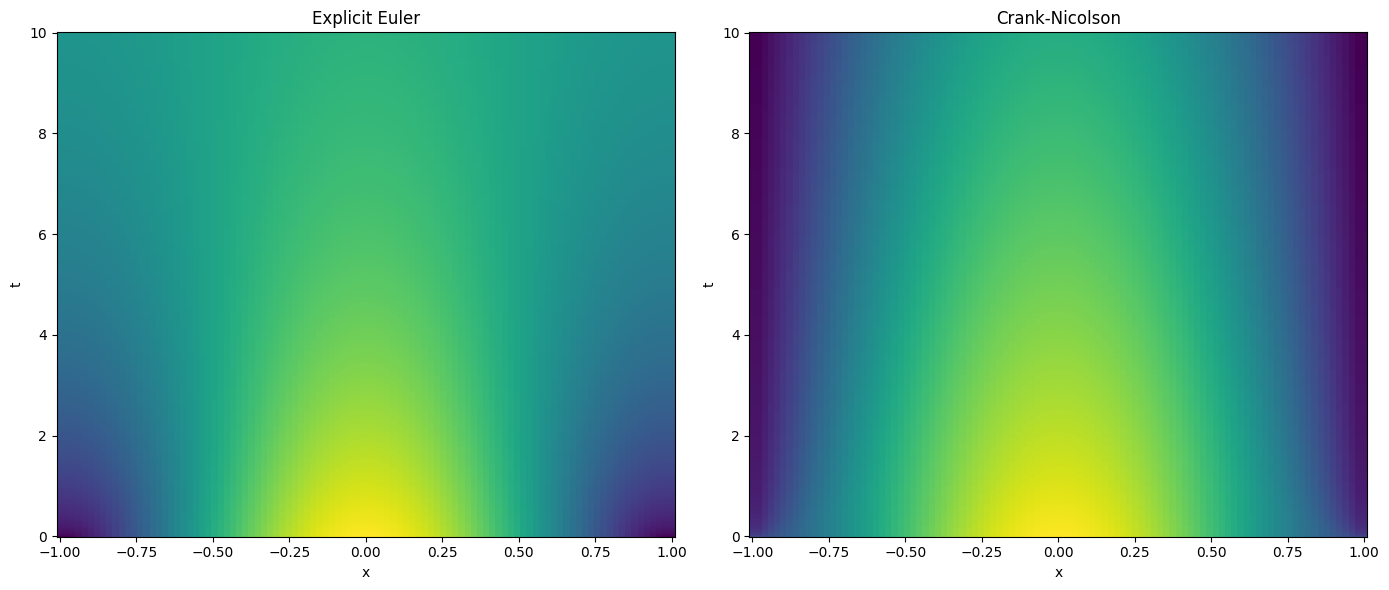

In [16]:
# Defining parameters
kappa = 0.020  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time
Nt = 1000  # number of timesteps

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 100

t = np.linspace(t_start, t_end, Nt)  # Create a vector of times
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

# Run the simulations
c_EE = EE(x, t, kappa) # explicit Euler
c_CN = CN(x, t, kappa) # Crank-Nicolson

# Plot the results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pcolormesh(x, t, c_EE.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Explicit Euler')

plt.subplot(1, 2, 2)
plt.pcolormesh(x, t, c_CN.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Crank-Nicolson')

plt.tight_layout()
plt.show()

Explicit Euler method took 0.08 seconds
Crank-Nicolson method took 0.09 seconds


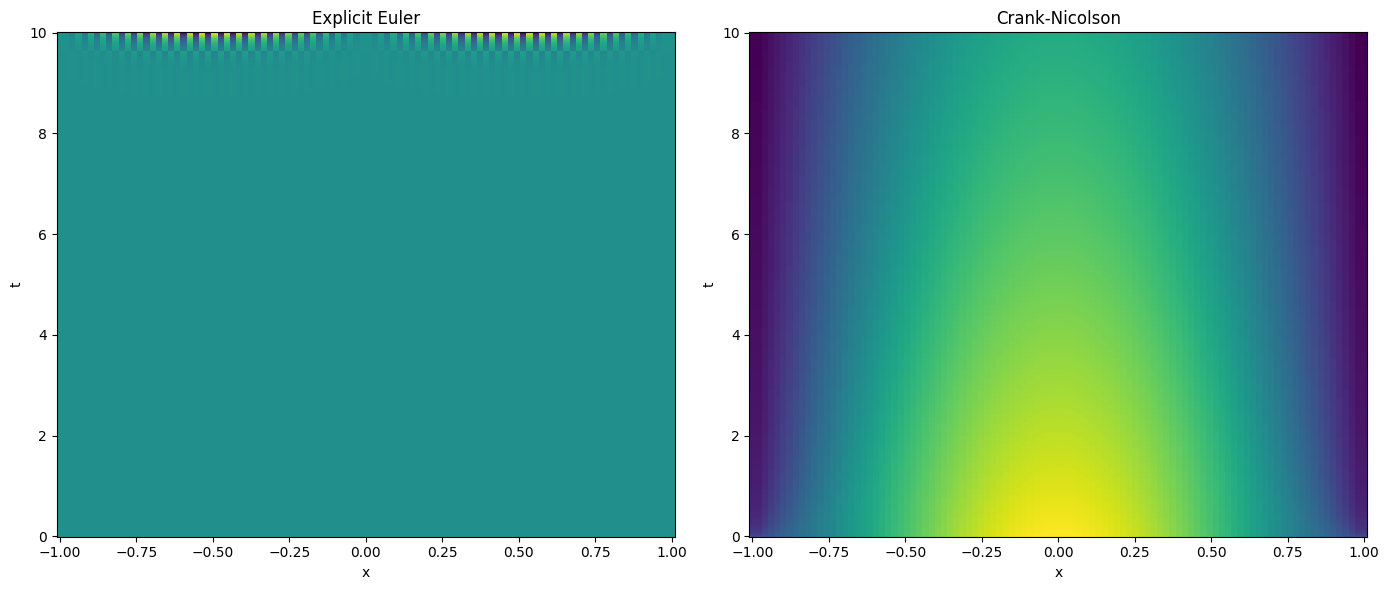

In [17]:
# Defining parameters
kappa = 0.021  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time
Nt = 1000  # number of timesteps

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 100

t = np.linspace(t_start, t_end, Nt)  # Create a vector of times
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

# Run the simulations
c_EE = EE(x, t, kappa) # explicit Euler
c_CN = CN(x, t, kappa) # Crank-Nicolson

# Plot the results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pcolormesh(x, t, c_EE.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Explicit Euler')

plt.subplot(1, 2, 2)
plt.pcolormesh(x, t, c_CN.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Crank-Nicolson')

plt.tight_layout()
plt.show()

**ANSWER:** From the above plots, we see that that there exists some $\kappa$ between 0.020 and 0.021 where the Explicit Euler method is no longer stable. This is a consequence of the fact that the Crank-Nicolson method is generally more stable given a set of parameters than the Explicit Euler method and thus require smaller timesteps to prevent divergence. Analytically, the Euler method is stable for values $\Delta t \leq \frac{\Delta x^2}{2\kappa}.$ In the above example, we require $\Delta t \leq 0.01.$  

### 2.2 Accuracy
<a id='section2pt2'></a>
Next, we will examine the accuracy of the numerical methods used above. In order to do this, it is useful to compare our numerical solutions with the exact solution to the diffusion equation. Below, write code to plot the exact solution and the numerical solution using explicit Euler and Crank-Nicolson at the final time ($t=10$). Note that you can use the exact solution to the diffusion equation in an unbounded domain in $x$ and keep in mind that the exact solution and numerical solutions will differ for later times when boundary effects are felt.

Explicit Euler method took 0.10 seconds
Crank-Nicolson method took 0.16 seconds


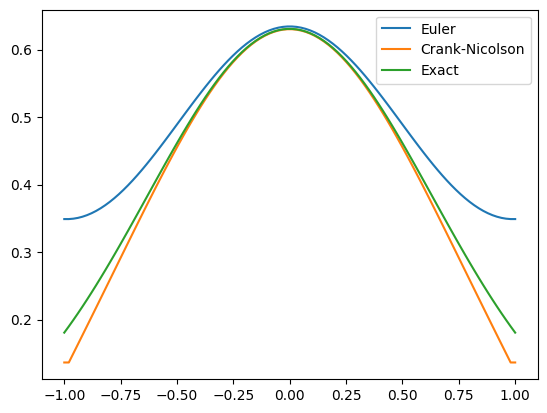

In [18]:
# Add code to plot exact and numerical solutions

# Defining parameters
kappa = 0.01  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time
Nt = 1000  # number of timesteps

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 100

t = np.linspace(t_start, t_end, Nt)  # Create a vector of times
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

# Solving numerical solution
c_EE = EE(x, t, kappa) # explicit Euler
c_CN = CN(x, t, kappa) # Crank-Nicolson

# Extract the numerical solution at t = 10.
time_to_evaluate = 10
plt.plot(x, c_EE[:,-1], label = "Euler")
plt.plot(x, c_CN[:,-1], label = "Crank-Nicolson")

# Plot exact solution
exact_solution = (4*np.pi*kappa*(time_to_evaluate + 10))**(-0.5)*np.exp(-x**2 / (4*kappa*(time_to_evaluate + 10))) # Note we add 10 seconds since the Crank-Nicolson and EE methods both have initial conditions at t_ic = 10.
plt.plot(x, exact_solution, label = "Exact")
plt.legend()

The difference between the exact solution and the numerical approximation can be quantified by various measures of error. The *local error* is the difference between the exact solution and the numerical approximation after one timestep. The *global error* is the difference between the solutions after a fixed amount of time (which includes the accumulation of multiple steps of local error). A method is first order accurate if the global error is linearly proportional to the timestep. A method is second order accurate if the global error varies quadratically with the timestep. Below, calculate and plot the global error for the Explicit Euler and Crank-Nicolson methods and use your results to infer the order of accuracy of each scheme.

PLOT GLOBAL ERROR FOR EACH SCHEME (1-2 figures) AND DISCUSS ORDER OF ACCURACY (2-3 sentences)

Explicit Euler method took 0.06 seconds
Explicit Euler method took 0.06 seconds
Explicit Euler method took 0.07 seconds
Explicit Euler method took 0.10 seconds
Explicit Euler method took 0.05 seconds
Explicit Euler method took 0.06 seconds
Explicit Euler method took 0.07 seconds
Explicit Euler method took 0.08 seconds
Explicit Euler method took 0.08 seconds
Explicit Euler method took 0.15 seconds
Explicit Euler method took 0.12 seconds


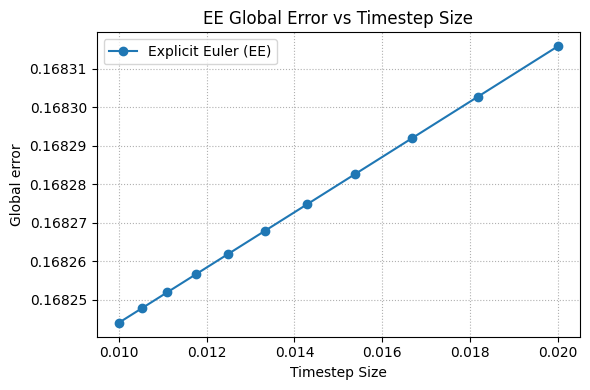

In [19]:
# Add code to plot error here

# Defining parameters
kappa = 0.01  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 100

# Initialize x
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

# Defining a global error caluclation function that takes in timesteps/
def global_error_calculation(timesteps):

  Nt = timesteps  # number of timesteps

  #Initialize t
  t = np.linspace(t_start, t_end, Nt)  # Create a vector of times

  # Getting the approximate solutions fom EE and CN
  c_EE = EE(x, t, kappa) # explicit Euler

  # Evaluating the exact solution at t = 10.
  exact_solution = (4*np.pi*kappa*(t_end + 10))**(-0.5)*np.exp(-x**2 / (4*kappa*(t_end + 10))) # Note we add 10 seconds since the Crank-Nicolson and EE methods both have initial conditions at t_ic = 10.

  # Calculating the error after a fixed amount of time
  ee_error = exact_solution - c_EE[:,-1]

  # Calculating global error using the maximum difference upon the domain.
  ee_global_error = max(np.abs(ee_error))

  return ee_global_error

# We select these values of timesteps in order to ensure stability.
timesteps_to_evaluate = [500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
ee_global_error_list = []
timestep_size = []

for timesteps in timesteps_to_evaluate:
  ee_global_error = global_error_calculation(timesteps)
  ee_global_error_list.append(ee_global_error)
  timestep_size.append(t_end/timesteps)

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(timestep_size, ee_global_error_list, marker='o', label='Explicit Euler (EE)')
plt.xlabel('Timestep Size')
plt.ylabel('Global error')
plt.title('EE Global Error vs Timestep Size')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

Crank-Nicolson method took 1.26 seconds
Crank-Nicolson method took 1.17 seconds
Crank-Nicolson method took 1.11 seconds
Crank-Nicolson method took 1.67 seconds
Crank-Nicolson method took 2.34 seconds
Crank-Nicolson method took 1.97 seconds
Crank-Nicolson method took 0.89 seconds
Crank-Nicolson method took 0.71 seconds
Crank-Nicolson method took 0.93 seconds
Crank-Nicolson method took 1.11 seconds
Crank-Nicolson method took 1.54 seconds


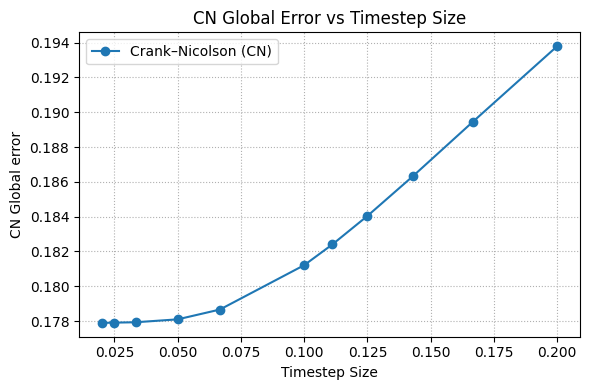

In [20]:
# Add code to plot error here

# Defining parameters
kappa = 0.01  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 1000

# Initialize x
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

# Defining a global error caluclation function that takes in timesteps/
def global_error_calculation(timesteps):

  Nt = timesteps  # number of timesteps

  #Initialize t
  t = np.linspace(t_start, t_end, Nt)  # Create a vector of times

  # Getting the approximate solutions from CN
  c_CN = CN(x, t, kappa) # Crank-Nicolson

  # Evaluating the exact solution at t = 10.
  exact_solution = (4*np.pi*kappa*(t_end + 10))**(-0.5)*np.exp(-x**2 / (4*kappa*(t_end + 10))) # Note we add 10 seconds since the Crank-Nicolson and EE methods both have initial conditions at t_ic = 10.

  # Calculating the error after a fixed amount of time
  cn_error = exact_solution - c_CN[:,-1]

  # Calculating global error using the maximum difference upon the domain.
  cn_global_error = max(np.abs(cn_error))

  return cn_global_error

# We selected these timesteps to ensure stability.
timesteps_to_evaluate = [50, 60, 70, 80, 90, 100, 150, 200, 300, 400, 500]
cn_global_error_list = []
timestep_size = []

for timesteps in timesteps_to_evaluate:
  cn_global_error = global_error_calculation(timesteps)
  cn_global_error_list.append(cn_global_error)
  timestep_size.append(t_end/timesteps)

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(timestep_size, cn_global_error_list, marker='o', label='Crank–Nicolson (CN)')
plt.xlabel('Timestep Size')
plt.ylabel('CN Global error')
plt.title('CN Global Error vs Timestep Size')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

**ANSWER:** Per **Theorem 9.1** in *An Introduction to Numerical Methods and Analysis* by Epperson (2013), we choose to evaluate global error upon the domain $x \in [-1, 1]$ by having error be $\max_{1 \leq i \leq N-1} |e_i|$  where $e_i$ is the error between the exact and approximate function. By carefully selecting $\Delta t$ such that the stability condition is ensured ($\Delta t \leq \frac{\Delta x^2}{2 \kappa}$) in the Explicit Euler method, we see in the "EE Global Error vs Timestep" plot that we have a linear relationship between the global error and the timestep, suggesting the Explicit Euler method is first order accurate. We also see a quadratic relationship between the global error and the timestep size evaluated using the Crank-Nicolson method which can be shown by seeing that the the increase in global error is four times as large for twice the size of a timestep increase. Hence, the Crank-Nicolson method is second order accurate. Note that as $\Delta t \rightarrow 0,$ then the errors need not approach zero since the global error is also dependent on the discretization upon the domain $\Delta x^2$ for both schemes.

Finally, select a given error tolerance and explore whether explicit Euler or Crank-Nicoslon is more efficient (faster) at generating solutions with error less than your error tolerance. Discuss your conclusion and add supporting figures if necessary.

Explicit Euler method took 0.01 seconds
Crank-Nicolson method took 0.11 seconds
Explicit Euler method took 0.01 seconds
Crank-Nicolson method took 0.06 seconds
Explicit Euler method took 0.01 seconds
Crank-Nicolson method took 0.12 seconds
Explicit Euler method took 0.03 seconds
Crank-Nicolson method took 0.07 seconds
Explicit Euler method took 0.02 seconds
Crank-Nicolson method took 0.08 seconds
Explicit Euler method took 0.04 seconds
Crank-Nicolson method took 0.11 seconds
Explicit Euler method took 0.06 seconds
Crank-Nicolson method took 0.07 seconds
Explicit Euler method took 0.03 seconds
Crank-Nicolson method took 0.12 seconds
Explicit Euler method took 0.08 seconds
Crank-Nicolson method took 0.11 seconds
Explicit Euler method took 0.05 seconds
Crank-Nicolson method took 0.04 seconds
Explicit Euler method took 0.03 seconds
Crank-Nicolson method took 0.04 seconds
Explicit Euler method took 0.04 seconds
Crank-Nicolson method took 0.06 seconds
Explicit Euler method took 0.06 seconds


/tmp/ipython-input-1195098015.py:24: RuntimeWarning: invalid value encountered in add
  c[:,k] = c[:,k-1] + dt * kappa * M @ c[:,k-1]


Crank-Nicolson method took 0.49 seconds
Explicit Euler method took 0.06 seconds
Crank-Nicolson method took 0.27 seconds
Explicit Euler method took 0.08 seconds
Crank-Nicolson method took 0.24 seconds
Explicit Euler method took 0.04 seconds
Crank-Nicolson method took 0.19 seconds
Explicit Euler method took 0.13 seconds
Crank-Nicolson method took 0.26 seconds
Explicit Euler method took 0.10 seconds
Crank-Nicolson method took 0.32 seconds
Explicit Euler method took 0.08 seconds
Crank-Nicolson method took 0.22 seconds
Explicit Euler method took 0.06 seconds
Crank-Nicolson method took 0.19 seconds
Explicit Euler method took 0.08 seconds
Crank-Nicolson method took 0.12 seconds
Explicit Euler method took 0.05 seconds
Crank-Nicolson method took 0.12 seconds
Explicit Euler method took 0.05 seconds
Crank-Nicolson method took 0.13 seconds
Explicit Euler method took 0.04 seconds
Crank-Nicolson method took 0.12 seconds
Explicit Euler method took 0.05 seconds
Crank-Nicolson method took 0.15 seconds


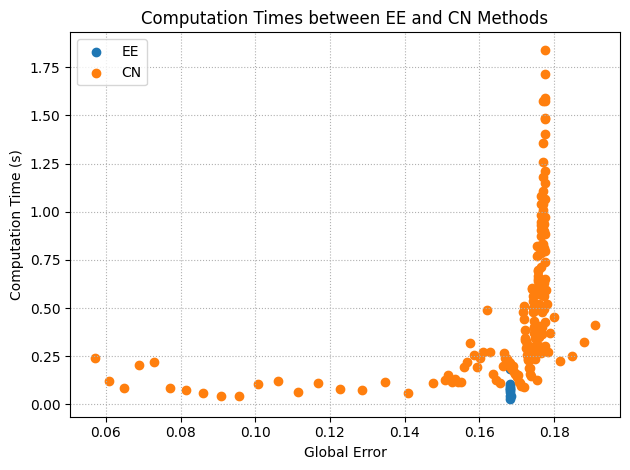

In [21]:
# We can conduct a pareto-optimization problem where we plot the time to calculate the global error against the global error.

# Redefining EE and CN functions to output the time it takes to solve.
def EE_optimization(x, t, kappa):
# This function timesteps the diffusion equation with homogeneous Neumann boundary conditions
# using the explicit Euler and second order finite difference methods

    start_time = time.time()  # Start a timer

    # Infer the timestep from the time array
    dt = t[1] - t[0]

    M = construct_M(x)  # Construct the coefficient matrix for the second derivative

    # Set the number of gridpoints in x and t
    Nx = len(x); Nt = len(t)

    # Create an empty sparse array to store the solution
    c = np.zeros((Nx, Nt))

    c[:, 0] = set_ics(x, kappa, 10)  # Set the initial condition

    for k in range(1, Nt):  # loop over the number of timesteps
      c[:,k] = c[:,k-1] + dt * kappa * M @ c[:,k-1]
      # Enforce the boundary conditions (no flux)
      c[0, k] = c[1, k]
      c[-1, k] = c[-2, k]

    end_time = time.time()  # Print the elapsed time

    print(f"Explicit Euler method took {end_time - start_time:.2f} seconds")

    return c, end_time - start_time

def CN_optimization(x, t, kappa):
# This function timesteps the diffusion equation with homogeneous Neumann boundary conditions
# using the explicit Euler and second order finite difference methods
    start_time = time.time()  # Start a timer

    # Infer the timestep from the time array
    dt = t[1] - t[0]

    M = construct_M(x)  # Construct the coefficient matrix for the second derivative

    # Set the number of gridpoints in x and t
    Nx = len(x); Nt = len(t)

    A = sp.eye(Nx) - 0.5 * dt * kappa * M  # This matrix appears on the LHS in the C-N scheme
    A_inv = spla.inv(A) # Calculate the inverse of A (this only needs to be done once)

    # Create an empty sparse array to store the solution
    c = np.zeros((Nx, Nt))

    c[:, 0] = set_ics(x, kappa, 10)  # Set the initial condition

    for k in range(1, Nt): # loop over the number of timesteps
        c[:, k] = A_inv @ (c[:, k-1] + 0.5 * dt * kappa * (M @ c[:, k-1]))
        # Enforce the boundary conditions
        c[0, k] = c[1, k]
        c[-1, k] = c[-2, k]

    end_time = time.time()  # Print the elapsed time

    print(f"Crank-Nicolson method took {end_time - start_time:.2f} seconds")

    return c, end_time - start_time

# Defining parameters
kappa = 0.01  # diffusivity
error_tolerance = 1 # error tolerance

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time

# Size of the physical domain
x_start = -1
x_end = 1

ee_error_list = []
ee_error_time = []
cn_error_list = []
cn_error_time = []
timesteps_to_evaluate = np.arange(50, 1000, 50)  # 50, 1000, ..., 950
position_steps_to_evaluate = np.arange(100, 1000, 100) # 100, 200, ..., 900

for position_step in position_steps_to_evaluate:

  for timestep in timesteps_to_evaluate:

    Nt = timestep  # number of timesteps
    Nx = position_step

    # Initialize x
    x = np.linspace(x_start, x_end, Nx)  # Create a vector for x
    #Initialize t
    t = np.linspace(t_start, t_end, Nt)  # Create a vector of times

    # Solving numerical solution
    c_EE, time_EE = EE_optimization(x, t, kappa) # explicit Euler
    c_CN, time_CN = CN_optimization(x, t, kappa) # Crank-Nicolson

    # Calculating exact solution at a specific time plus 10 (see notes above)
    exact_solution = (4*np.pi*kappa*(t_end + 10))**(-0.5)*np.exp(-x**2 / (4*kappa*(t_end+10)))

    # Calculating the global error at the end
    ee_error = max(np.abs(exact_solution - c_EE[:,-1]))
    cn_error = max(np.abs(exact_solution - c_CN[:,-1]))

    # Only storing error and computation times if error is less than tolerance.
    if ee_error < error_tolerance:
      ee_error_list.append(ee_error)
      ee_error_time.append(time_EE)

    if cn_error < error_tolerance:
      cn_error_list.append(cn_error)
      cn_error_time.append(time_CN)

# Error tolerance on y-axis and time to compute on the x-axis
plt.scatter(ee_error_list, ee_error_time, label = 'EE')
plt.scatter(cn_error_list, cn_error_time, label = 'CN')
plt.xlabel('Global Error')
plt.ylabel('Computation Time (s)')
plt.title('Computation Times between EE and CN Methods')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

INSERT DISCUSSION OF ERROR HERE (~1 paragraph).  OPTIONALLY ADD PLOTS BY INSERTING A CODE BLOCK BELOW.

**ANSWER:** By iterating through different values of $\Delta x$ and $\Delta t,$ I can assess the performance of both the EE and CN methods given different parameters. With an error tolerance of 1, we can see that the EE method is particularly sensitive to the parameters as variations in the parameters cause instability in the solution for reasons mentioned in my answer in section 2.1. As a result, the stable approximations resulting from the EE method hover around both the same error and computation time as compared to the CN method. On the other hand, we can see that the CN method produces a solution for more parameters than the EE method is able to. We can see that although errors can be relatively fixed, the computation time can greatly vary. This suggests the existence of parameters that are computationally expensive with little further gain on a more accurate method. Counterintuitively, we also see CN solutions that had lower error and computational time.

### 2.3 Boundary conditions for Crank-Nicolson scheme
<a id='section2pt3'></a>

The application of the boundary conditions for the Crank-Nicolson method isn't quite right in the script above (but the boundary conditions aren't very important in this example). Account for the boundary conditions by modifying the coefficient matrix. This should ensure that the boundary conditions are applied to the implicit and explicit terms involved in the Crank-Nicolson update. Plot your results below and verify that the boundary conditions are satisfied.  How would you handle fixed value (Dirichlet) and fixed gradient (Neumann) boundary conditions?

Crank-Nicolson method took 0.05 seconds
Crank-Nicolson method took 0.17 seconds


Text(0.5, 1.0, 'Crank-Nicolson (Old Method)')

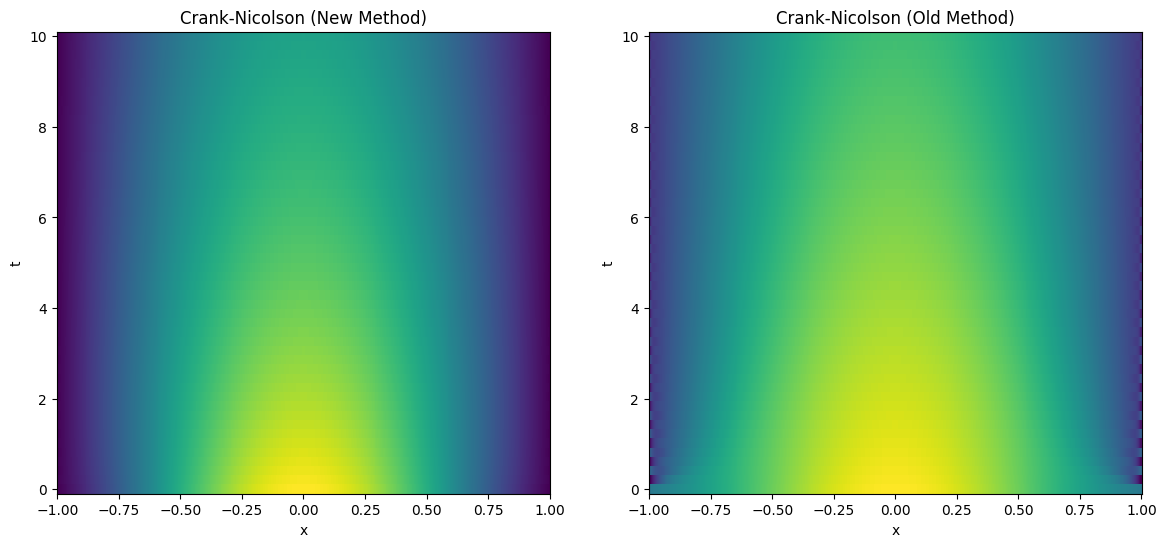

In [22]:
from scipy.sparse.linalg import spsolve

# Defining parameters
kappa = 0.02  # diffusivity

# Timestepping parameters
t_start = 0  # start time (note that this is not the same time used to evaluate the exact solution to set the ICs)
t_end = 10  # end time
Nt = 50  # number of timesteps

# Size of the physical domain
x_start = -1
x_end = 1
Nx = 500

t = np.linspace(t_start, t_end, Nt)  # Create a vector of times
x = np.linspace(x_start, x_end, Nx)  # Create a vector for x

def construct_M_boundary(x):
    # Build a coefficient matrix, such that M*c is the discrete version of d^2/dx^2(c)
    dx = x[1] - x[0]  # Infer the uniform grid spacing
    M = (np.diag(np.ones(Nx - 1), -1) - 2 * np.diag(np.ones(Nx), 0) + np.diag(np.ones(Nx - 1), 1)) / dx ** 2

    # Homogeneous Neumann boundary conditions (no flux)
    M[0, 0] = 2
    M[0, 1] = -2
    M[Nx - 1, Nx - 1] = 2
    M[Nx - 1, Nx - 2] = -2

    M = sp.csr_matrix(M)  # Turn M into a sparse matrix to save memory and improve speed
    return M

def CN_boundary_conditions(x, t, kappa):
    # This function timesteps the diffusion equation with specified boundary conditions
    # using the Crank-Nicolson and second order finite difference methods

    start_time = time.time()  # Start a timer

    # Infer the timestep from the time array
    dt = t[1] - t[0]

    # Set the number of gridpoints in x and t
    Nx = len(x)
    Nt = len(t)

    # Create an empty sparse array to store the solution
    c = np.zeros((Nx, Nt))

    # Set the initial condition
    c[:, 0] = set_ics(x, kappa, 10)

    # Construct the coefficient matrix for the second derivative based on BC type
    M = construct_M_boundary(x)

    for k in range(1, Nt):  # loop over the number of timesteps
        # Construct the A matrix and right-hand side vector based on BC type
        A = sp.eye(Nx) - 0.5 * dt * kappa * M
        b = c[:, k - 1] + 0.5 * dt * kappa * (M @ c[:, k - 1])
        # For Neumann, the boundary conditions are incorporated into M, so we can solve directly without enforcing the boundaries.
        c[:, k] = spla.spsolve(A, b)

    end_time = time.time()  # Print the elapsed time

    print(f"Crank-Nicolson method took {end_time - start_time:.2f} seconds")

    return c

# Run simulations with different M which accounts for the boundary conditions.
c_CN_boundary = CN_boundary_conditions(x, t, kappa)
c_CN = CN(x, t, kappa) # Crank-Nicolson

# Plot the results side-by-side
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pcolormesh(x, t, c_CN_boundary.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Crank-Nicolson (New Method)')

plt.subplot(1, 2, 2)
plt.pcolormesh(x, t, c_CN.T, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Crank-Nicolson (Old Method)')

Max Flux at left boundary: 0.8847171203609373
Max Flux at right boundary: 0.8847171203609097


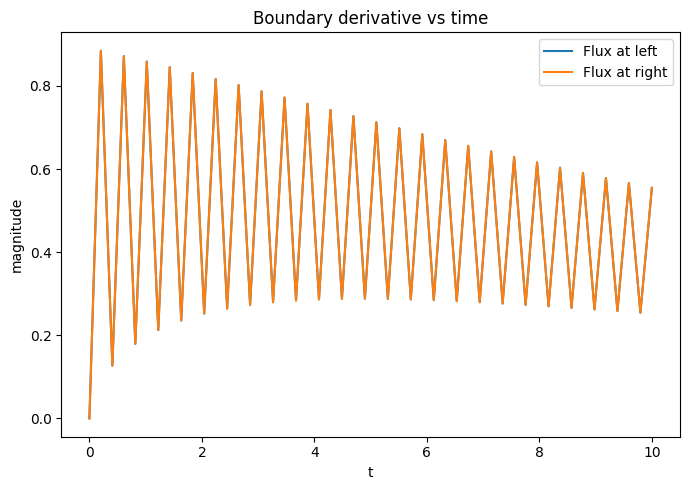

In [23]:
 dx = x[1] - x[0]

# If your solution is named c_CN_boundary with shape (Nx, Nt):
left_derivative  = (c_CN_boundary[1, :]  - c_CN_boundary[0, :])  / dx
right_derivative = (c_CN_boundary[-1, :] - c_CN_boundary[-2, :]) / dx

print("Max Flux at left boundary:",  np.max(np.abs(left_derivative)))
print("Max Flux at right boundary:", np.max(np.abs(right_derivative)))

plt.figure(figsize=(7,5))
plt.plot(t, np.abs(left_derivative),  label='Flux at left')
plt.plot(t, np.abs(right_derivative), label='Flux at right')
plt.xlabel('t'); plt.ylabel('magnitude'); plt.title('Boundary derivative vs time')
plt.legend(); plt.tight_layout()

**ANSWER:** Because of the *homogeneous* Neumann boundary conditions, we know that $\frac{\partial T}{\partial x}|_{x=0} = \frac{\partial T}{\partial x}|_{x=N-1} = 0.$ From the central finite difference scheme, we then know that $\frac{\partial T}{\partial x}|_{x=0} = \frac{T(x_1, t) - T(x_{-1}, t)}{2 \Delta x} = 0.$ This suggests that $T(x_1, t) = T(x_{-1}, t).$ Likewise, $T(x_{N-2}, t) = T(x_N,t).$ We can substitute these values into the second derivative approximation $\frac{\partial^2 T}{\partial x^2} \approx \frac{T(x_{i+1}, t) - 2T(x_{i}, t) + T(x_{i-1}, t)}{\Delta x^2}$ to compensate for the fact that $\frac{\partial^2 T}{\partial x^2}$ can not be evaluated at the boundaries. Thus, we have $\frac{\partial^2 T}{\partial x^2}(x_0, t) \approx \frac{2T(x_{1}, t) - 2T(x_{0}, t)}{\Delta x^2}.$ A similar answer is found at the other boundary. We can thus change the matrix *M* by adding a -2 and a 2 in the corresponding indices. As we can see in the two diffusion plots, the old method, while it forces the boundary condition to hold, has some discontinuities at the boundaries in the earlier times. On the contrary, the new method incorporates both the implicit and explicit terms and is visually smoother so long as we are okay with a specific error tolerance given by the numerical method.

ADD DISCUSSION OF DIRICHLET AND NEUMANN BOUNDARY CONDITIONS HERE (NO CODE NEEDED)

**ANSWER FOR NEUMANN:** Note that in the above answer we assume a homogeneous Neumann boundary condition which asserts that the derivative at the boundary is 0. For general Neumann boundary conditions, we have $\frac{\partial T}{\partial x}|_{x=0} = \alpha$ and $\frac{\partial T}{\partial x}|_{x=N-1} = \beta.$ Using the same method as above, we can assert the following relationships: $\frac{T(x_1, t) - T(x_{-1}, t)}{2 \Delta x} = \alpha$ and $\frac{T(x_{N}, t) - T(x_{N-2}, t)}{2 \Delta x} = \beta.$ As a result, $T(x_{-1}, t) = T(x_1,t) - 2\alpha \Delta x$ and $T(x_n, t) = T(x_{N-2}, t) + 2\beta \Delta x.$ By substitutng this into our second order derivative approximation, we have $\frac{\partial^2 T}{\partial x^2}(x_0, t) \approx \frac{2T(x_1,t) - 2T(x_0, t) - 2\alpha \Delta x}{\Delta x^2}$ and $\frac{\partial^2 T}{\partial x^2}(x_{N-1}, t) \approx \frac{2T(x_{N-2},t) - 2T(x_{N-1}, t) + 2\beta \Delta x}{\Delta x^2}.$ Thus the new operator is $MT + q$ wjere $q_0 = \frac{-2 \alpha}{\Delta x}$ and $q_{N-1} =\frac{2\beta}{\Delta x}$ and $q_i =0$ everywhere else.

**ANSWER FOR DIRICHLET:** For a general Dirichlet boundary condition we have $T(0, t) = \alpha$ and $T(N-1, t) = \beta$ for all times $t$ in the time domain. Additionally, because the boundary values are fixed, we now only need to conduct a numerical analysis across the space domain besides at the end points. If there are $N$ points in the space domain, the new matrix operator must be of size $ N -2 \times N - 2.$ This new matrix $M_D$ will be like the original matrix $M$ with the diagonal having $-2$ surrounded by 1's in the row. However, our new matrix operator will act upon a shortened vector $T_D = [T(x_1, t), T(x_2, t), ..., T(x_{N-2}, t)]^T.$ Because of this, we forgo the contributions of $T(x_0,t)$ and $T(x_{N-1},t )$ in the approximation of the second derivative. Hence, we must add another $N -2$ sized vector $q_D = [T(x_0, t), 0, ..., 0, T(x_{N-1}, t)]^T$ to complete the approximation. Because of the Dirichlet boundary condition, we know that $T(0, t) = \alpha$ and $T(N-1, t) = \beta$ for all times $t$ in the time domain. Thus, the final operation the total operation is $M_DT_D + q_D$ where $q_D = [\alpha, 0, ..., 0, \beta]^T.$